# Online Retail Data Analysis

**Dataset:** Online Retail Transactions — UK-based e-commerce company  
**Period:** December 2010 – December 2011  

---

**Table of Contents**

1. Libraries & Configuration
2. Load Data (Excel to CSV)
3. Data Overview
4. Data Cleaning
5. Feature Engineering
6. Distributions & Correlations
7. Sales Trend Analysis
8. Customer Analysis & RFM Segmentation
9. Product Analysis
10. Geographic Analysis
11. Summary Dashboard

---
## 1. Libraries & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

---
## 2. Load Data (Excel to CSV)

Read the original Excel file, save it as CSV for faster future access, then load it.

In [2]:
EXCEL_PATH = 'Online Retail.xlsx'
CSV_PATH   = 'online_retail.csv'

# Convert Excel to CSV only if the CSV does not already exist
if not os.path.exists(CSV_PATH):
    print('Reading Excel file...')
    raw_df = pd.read_excel(EXCEL_PATH, engine='openpyxl')
    raw_df.to_csv(CSV_PATH, index=False, encoding='utf-8')
    print(f'Saved as: {CSV_PATH}')
else:
    print(f'CSV already exists: {CSV_PATH}')

# Load from CSV with proper dtypes
df_raw = pd.read_csv(
    CSV_PATH,
    encoding='utf-8',
    dtype={'InvoiceNo': str, 'StockCode': str, 'CustomerID': str}
)

print(f'Rows: {df_raw.shape[0]:,}   Columns: {df_raw.shape[1]}')

CSV already exists: online_retail.csv
Rows: 541,909   Columns: 8


---
## 3. Data Overview

In [3]:
# First five rows
df_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [4]:
# Data types and shape
print('Shape:', df_raw.shape)
print()
print(df_raw.dtypes)

Shape: (541909, 8)

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID         str
Country            str
dtype: object


In [5]:
# Missing values per column
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})[missing > 0]

,Missing Count,Missing %
Description,1454,0.27
CustomerID,135080,24.93


In [6]:
# Descriptive statistics for numeric columns
df_raw[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,"541,909.00","541,909.00"
mean,9.55,4.61
std,218.08,96.76
min,"-80,995.00","-11,062.06"
25%,1.00,1.25
50%,3.00,2.08
75%,10.00,4.13
max,"80,995.00","38,970.00"


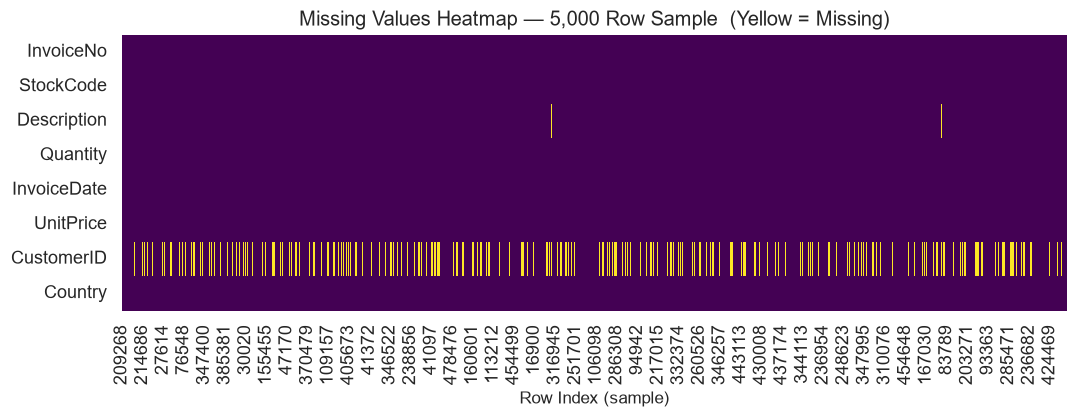

In [7]:
# Missing values heatmap (5,000-row sample for readability)
fig, ax = plt.subplots(figsize=(10, 4))
sample = df_raw.sample(5000, random_state=42).isnull()
sns.heatmap(sample.T, cbar=False, yticklabels=df_raw.columns,
            cmap='viridis', ax=ax)
ax.set_title('Missing Values Heatmap — 5,000 Row Sample  (Yellow = Missing)')
ax.set_xlabel('Row Index (sample)')
plt.tight_layout()
plt.show()

---
## 4. Data Cleaning

Steps applied:
- Parse `InvoiceDate` as datetime
- Remove cancelled invoices (prefix `C`)
- Remove rows where `Quantity <= 0` or `UnitPrice <= 0`
- Drop rows with missing `CustomerID`
- Drop exact duplicate rows

In [8]:
df = df_raw.copy()
rows_before = len(df)
print(f'Rows before cleaning: {rows_before:,}')

# Parse dates
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove cancelled orders
cancelled = df['InvoiceNo'].str.startswith('C')
df = df[~cancelled]
print(f'Cancelled orders removed : {cancelled.sum():,}')

# Remove non-positive Quantity and UnitPrice
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Drop rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Drop duplicates
before_dup = len(df)
df = df.drop_duplicates()
print(f'Duplicate rows removed   : {before_dup - len(df):,}')

rows_after = len(df)
print(f'\nRows after  cleaning: {rows_after:,}')
print(f'Total rows removed  : {rows_before - rows_after:,}  ({(rows_before - rows_after)/rows_before*100:.1f}%)')

Rows before cleaning: 541,909
Cancelled orders removed : 9,288
Duplicate rows removed   : 5,192

Rows after  cleaning: 392,692
Total rows removed  : 149,217  (27.5%)


---
## 5. Feature Engineering

New columns derived from existing data:

| Column | Description |
|--------|-------------|
| `TotalRevenue` | `Quantity × UnitPrice` |
| `Year` / `Month` / `MonthName` | Calendar components |
| `YearMonth` | Period column for monthly aggregation |
| `DayOfWeek` | Name of the weekday |
| `Hour` | Hour of the transaction |

In [9]:
df['TotalRevenue'] = df['Quantity'] * df['UnitPrice']

df['Year']      = df['InvoiceDate'].dt.year
df['Month']     = df['InvoiceDate'].dt.month
df['MonthName'] = df['InvoiceDate'].dt.strftime('%b')
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour']      = df['InvoiceDate'].dt.hour

print(f'Total Revenue : {df["TotalRevenue"].sum():,.2f} GBP')
print(f'Date Range    : {df["InvoiceDate"].min().date()}  to  {df["InvoiceDate"].max().date()}')

df[['InvoiceNo', 'InvoiceDate', 'Quantity', 'UnitPrice',
     'TotalRevenue', 'MonthName', 'DayOfWeek', 'Hour']].head()

Total Revenue : 8,887,208.89 GBP
Date Range    : 2010-12-01  to  2011-12-09


,InvoiceNo,InvoiceDate,Quantity,UnitPrice,TotalRevenue,MonthName,DayOfWeek,Hour
0,536365,2010-12-01 08:26:00,6,2.55,15.30,Dec,Wednesday,8
1,536365,2010-12-01 08:26:00,6,3.39,20.34,Dec,Wednesday,8
2,536365,2010-12-01 08:26:00,8,2.75,22.00,Dec,Wednesday,8
3,536365,2010-12-01 08:26:00,6,3.39,20.34,Dec,Wednesday,8
4,536365,2010-12-01 08:26:00,6,3.39,20.34,Dec,Wednesday,8


---
## 6. Distributions & Correlations

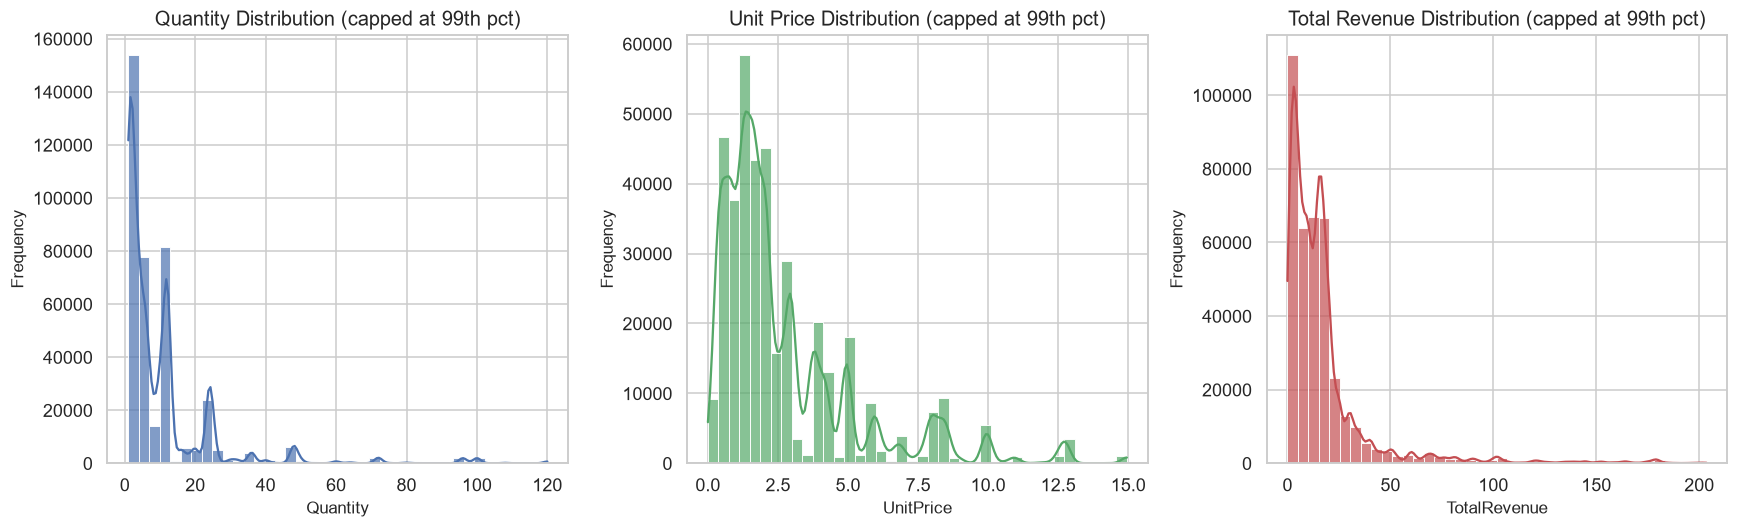

In [10]:
# Distribution of key numeric variables (capped at 99th percentile)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_data = [
    ('Quantity',     df[df['Quantity']      <= df['Quantity'].quantile(0.99)]['Quantity'],     '#4C72B0'),
    ('Unit Price',   df[df['UnitPrice']     <= df['UnitPrice'].quantile(0.99)]['UnitPrice'],   '#55A868'),
    ('Total Revenue',df[df['TotalRevenue']  <= df['TotalRevenue'].quantile(0.99)]['TotalRevenue'], '#C44E52'),
]

for ax, (label, data, color) in zip(axes, plot_data):
    sns.histplot(data, bins=40, kde=True, color=color, ax=ax, alpha=0.7)
    ax.set_title(f'{label} Distribution (capped at 99th pct)')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

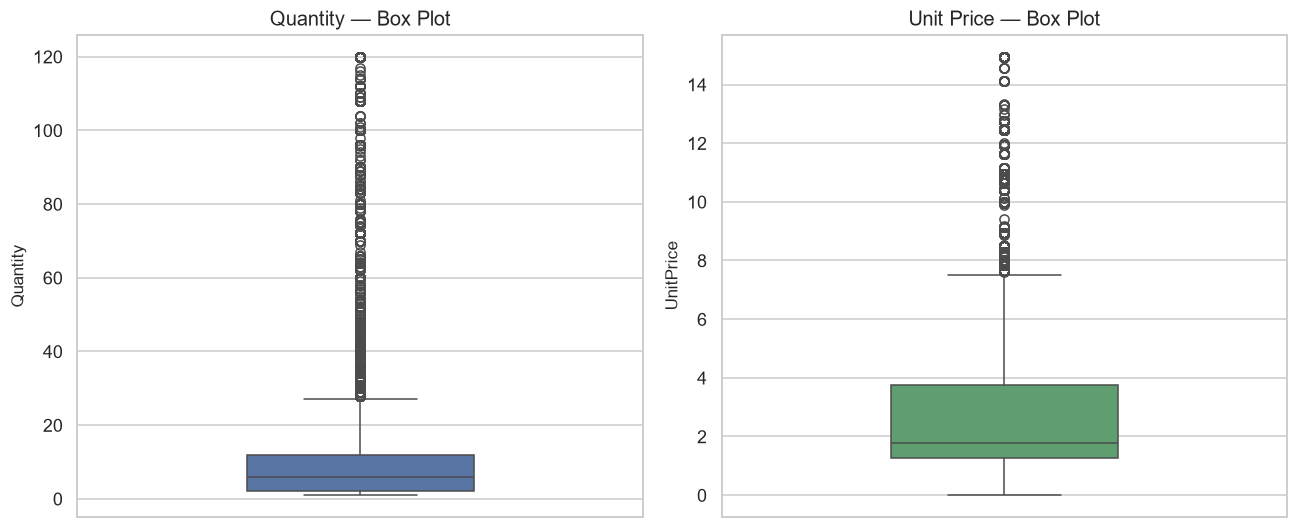

In [11]:
# Box plots to identify outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

q99_qty   = df['Quantity'].quantile(0.99)
q99_price = df['UnitPrice'].quantile(0.99)

sns.boxplot(y=df[df['Quantity']  <= q99_qty]['Quantity'],   color='#4C72B0', width=0.4, ax=axes[0])
axes[0].set_title('Quantity — Box Plot')

sns.boxplot(y=df[df['UnitPrice'] <= q99_price]['UnitPrice'], color='#55A868', width=0.4, ax=axes[1])
axes[1].set_title('Unit Price — Box Plot')

plt.tight_layout()
plt.show()

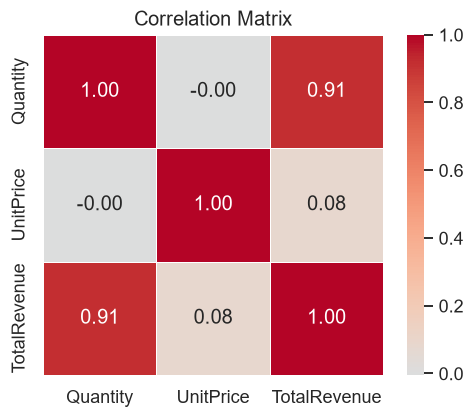

In [12]:
# Correlation matrix
corr = df[['Quantity', 'UnitPrice', 'TotalRevenue']].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

---
## 7. Sales Trend Analysis

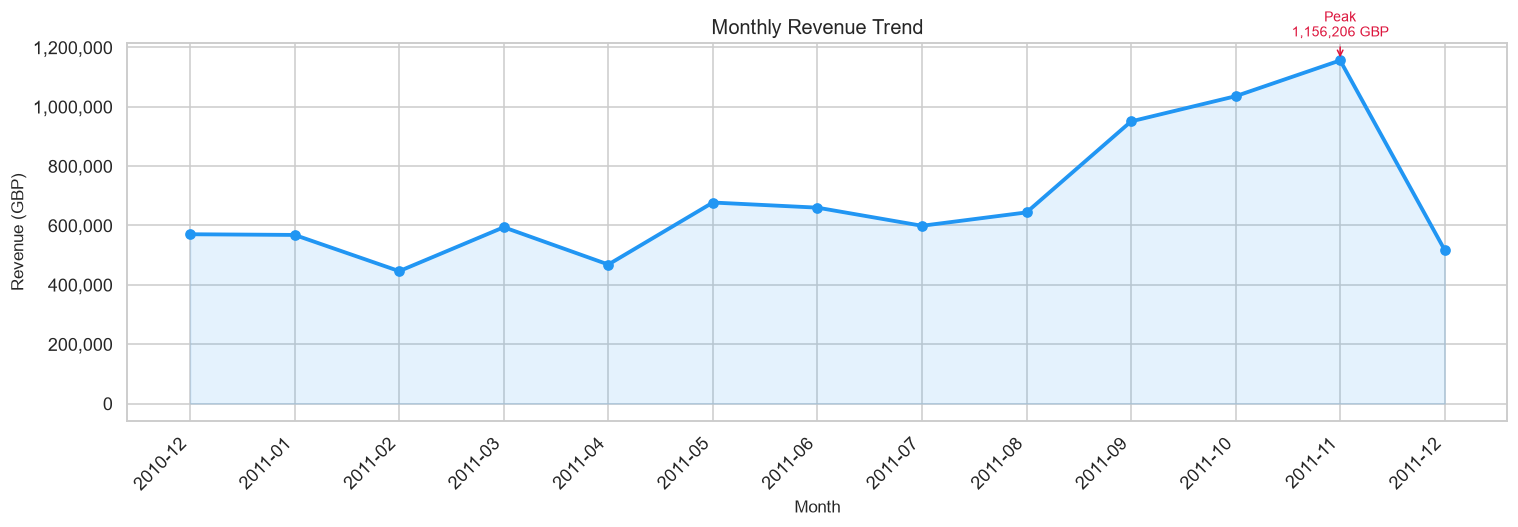

In [13]:
# Monthly revenue trend
monthly_revenue = (
    df.groupby('YearMonth')['TotalRevenue']
    .sum()
    .reset_index()
)
monthly_revenue['YM_str'] = monthly_revenue['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_revenue['YM_str'], monthly_revenue['TotalRevenue'],
        marker='o', linewidth=2.5, color='#2196F3', markersize=6)
ax.fill_between(monthly_revenue['YM_str'], monthly_revenue['TotalRevenue'],
                alpha=0.12, color='#2196F3')

# Annotate peak month
peak_idx = monthly_revenue['TotalRevenue'].idxmax()
peak_val = monthly_revenue.loc[peak_idx, 'TotalRevenue']
peak_lbl = monthly_revenue.loc[peak_idx, 'YM_str']
ax.annotate(
    f'Peak\n{peak_val:,.0f} GBP',
    xy=(peak_lbl, peak_val),
    xytext=(peak_lbl, peak_val * 1.07),
    ha='center', fontsize=9, color='crimson',
    arrowprops=dict(arrowstyle='->', color='crimson')
)

ax.set_title('Monthly Revenue Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (GBP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

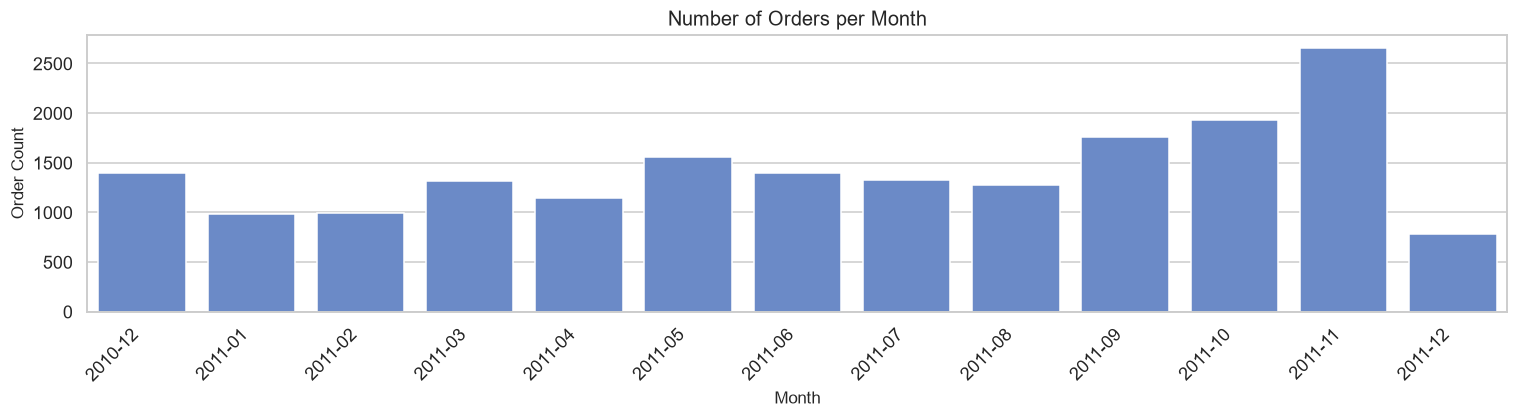

In [14]:
# Monthly order count
monthly_orders = (
    df.groupby('YearMonth')['InvoiceNo']
    .nunique()
    .reset_index()
    .rename(columns={'InvoiceNo': 'OrderCount'})
)
monthly_orders['YM_str'] = monthly_orders['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(14, 4))
sns.barplot(data=monthly_orders, x='YM_str', y='OrderCount',
            color='#5C85D6', ax=ax)
ax.set_title('Number of Orders per Month')
ax.set_xlabel('Month')
ax.set_ylabel('Order Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

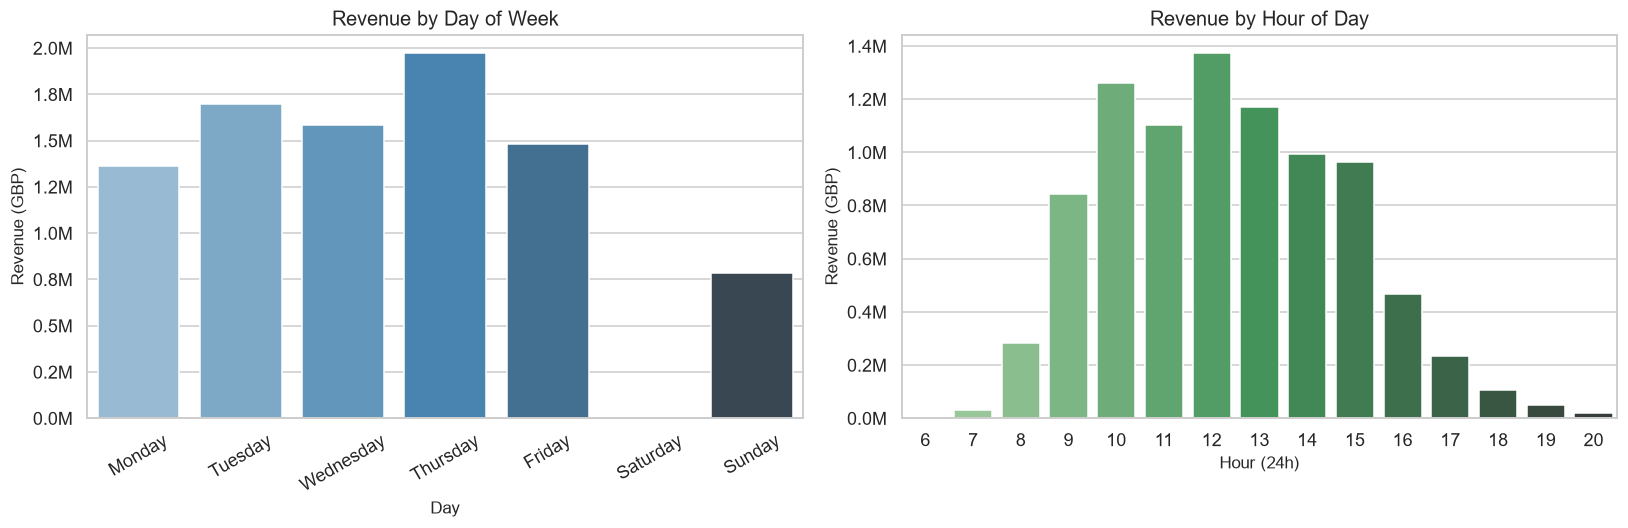

In [15]:
# Revenue by day of week and by hour of day
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_rev = (
    df.groupby('DayOfWeek')['TotalRevenue']
    .sum()
    .reindex(day_order)
    .reset_index()
)
hour_rev = df.groupby('Hour')['TotalRevenue'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=day_rev, x='DayOfWeek', y='TotalRevenue',
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Revenue by Day of Week')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Revenue (GBP)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=hour_rev, x='Hour', y='TotalRevenue',
            palette='Greens_d', ax=axes[1])
axes[1].set_title('Revenue by Hour of Day')
axes[1].set_xlabel('Hour (24h)')
axes[1].set_ylabel('Revenue (GBP)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

---
## 8. Customer Analysis & RFM Segmentation

In [16]:
# Customer-level aggregation
customer_df = (
    df.groupby('CustomerID')
    .agg(
        TotalSpent  = ('TotalRevenue', 'sum'),
        OrderCount  = ('InvoiceNo',    'nunique'),
        ItemsBought = ('Quantity',     'sum'),
    )
    .reset_index()
)

print(f'Unique customers : {len(customer_df):,}')
print(f'Avg spend        : {customer_df["TotalSpent"].mean():,.2f} GBP')
print(f'Avg orders       : {customer_df["OrderCount"].mean():.1f}')
print()
customer_df.nlargest(10, 'TotalSpent')[['CustomerID', 'TotalSpent', 'OrderCount', 'ItemsBought']]

Unique customers : 4,338
Avg spend        : 2,048.69 GBP
Avg orders       : 4.3



,CustomerID,TotalSpent,OrderCount,ItemsBought
1689,14646,"280,206.02",73,196915
4201,18102,"259,657.30",60,64124
3728,17450,"194,390.79",46,69973
3008,16446,"168,472.50",2,80997
1879,14911,"143,711.17",201,80240
55,12415,"124,914.53",21,77374
1333,14156,"117,210.08",55,57768
3771,17511,"91,062.38",31,64549
2702,16029,"80,850.84",63,40108
0,12346,"77,183.60",1,74215


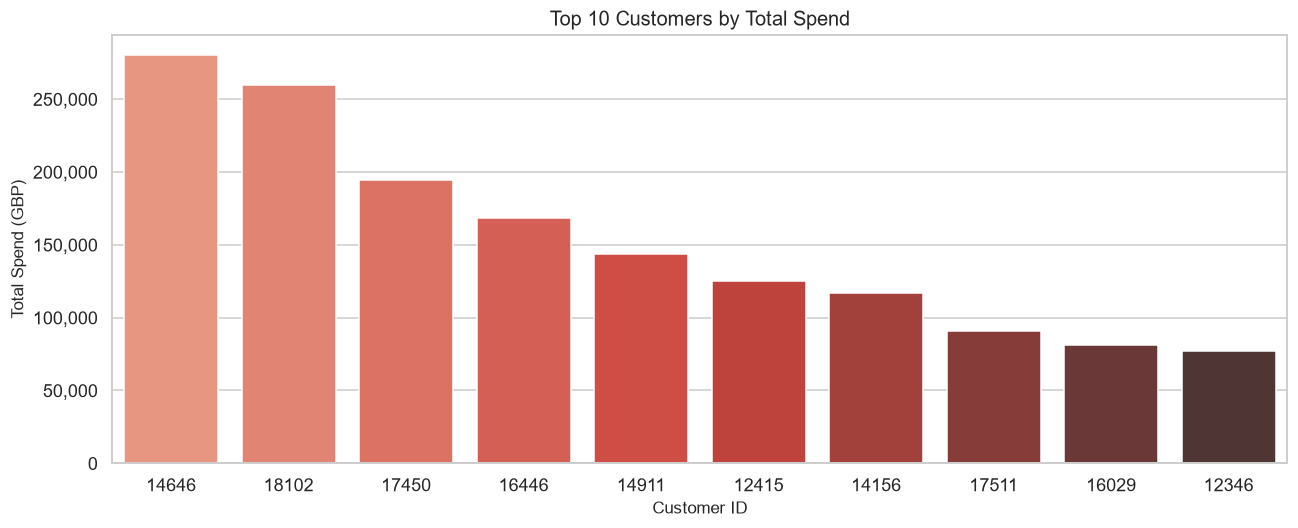

In [17]:
# Top 10 customers by total spend
top10_cust = customer_df.nlargest(10, 'TotalSpent')

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=top10_cust, x='CustomerID', y='TotalSpent',
            palette='Reds_d', ax=ax)
ax.set_title('Top 10 Customers by Total Spend')
ax.set_xlabel('Customer ID')
ax.set_ylabel('Total Spend (GBP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In [18]:
# RFM Segmentation
# Recency: days since last purchase
# Frequency: number of distinct invoices
# Monetary: total revenue

ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby('CustomerID')
    .agg(
        Recency   = ('InvoiceDate',  lambda x: (ref_date - x.max()).days),
        Frequency = ('InvoiceNo',    'nunique'),
        Monetary  = ('TotalRevenue', 'sum')
    )
    .reset_index()
)

# Score 1–4 (4 = best)
rfm['R_Score'] = pd.qcut(rfm['Recency'],                         q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),  q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),   q=4, labels=[1, 2, 3, 4])

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(int) +
    rfm['F_Score'].astype(int) +
    rfm['M_Score'].astype(int)
)

def segment(score):
    if score >= 10: return 'Champions'
    elif score >= 7: return 'Loyal'
    elif score >= 5: return 'Potential'
    else:            return 'At Risk'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

print('RFM Segment distribution:')
print(rfm['Segment'].value_counts())
rfm.head()

RFM Segment distribution:
Segment
Loyal        1276
Champions    1267
Potential     989
At Risk       806
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,1,"77,183.60",1,1,4,6,Potential
1,12347,2,7,"4,310.00",4,4,4,12,Champions
2,12348,75,4,"1,797.24",2,3,4,9,Loyal
3,12349,19,1,"1,757.55",3,1,4,8,Loyal
4,12350,310,1,334.40,1,1,2,4,At Risk


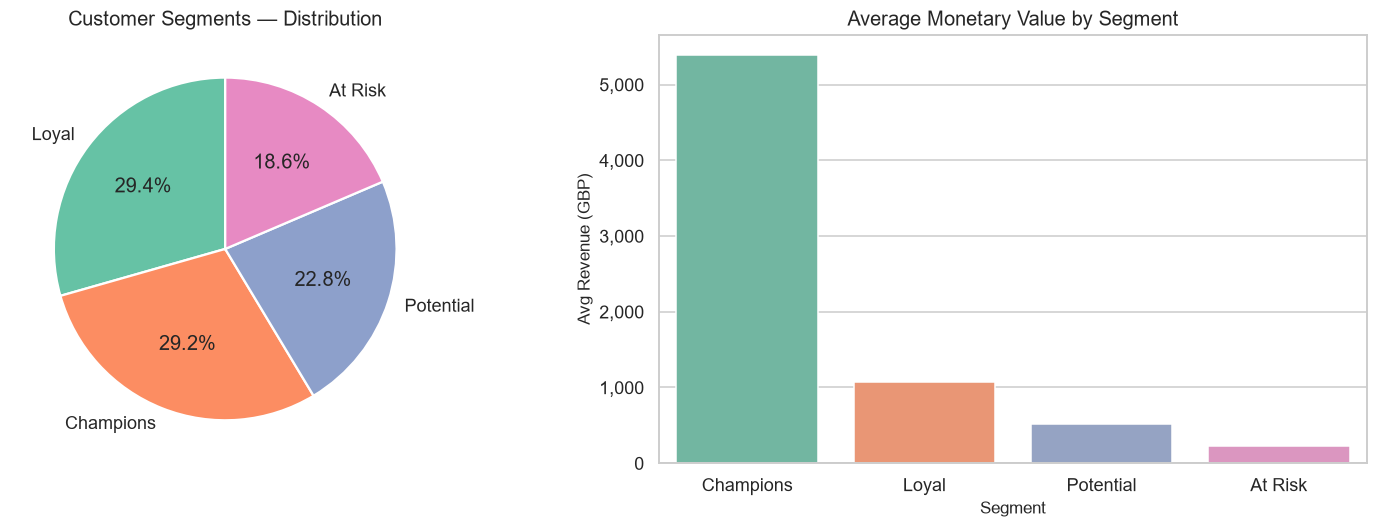

In [19]:
# RFM segment charts
seg_counts   = rfm['Segment'].value_counts()
seg_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    seg_counts,
    labels=seg_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2', len(seg_counts)),
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[0].set_title('Customer Segments — Distribution')

sns.barplot(x=seg_monetary.index, y=seg_monetary.values,
            palette='Set2', ax=axes[1])
axes[1].set_title('Average Monetary Value by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Avg Revenue (GBP)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

---
## 9. Product Analysis

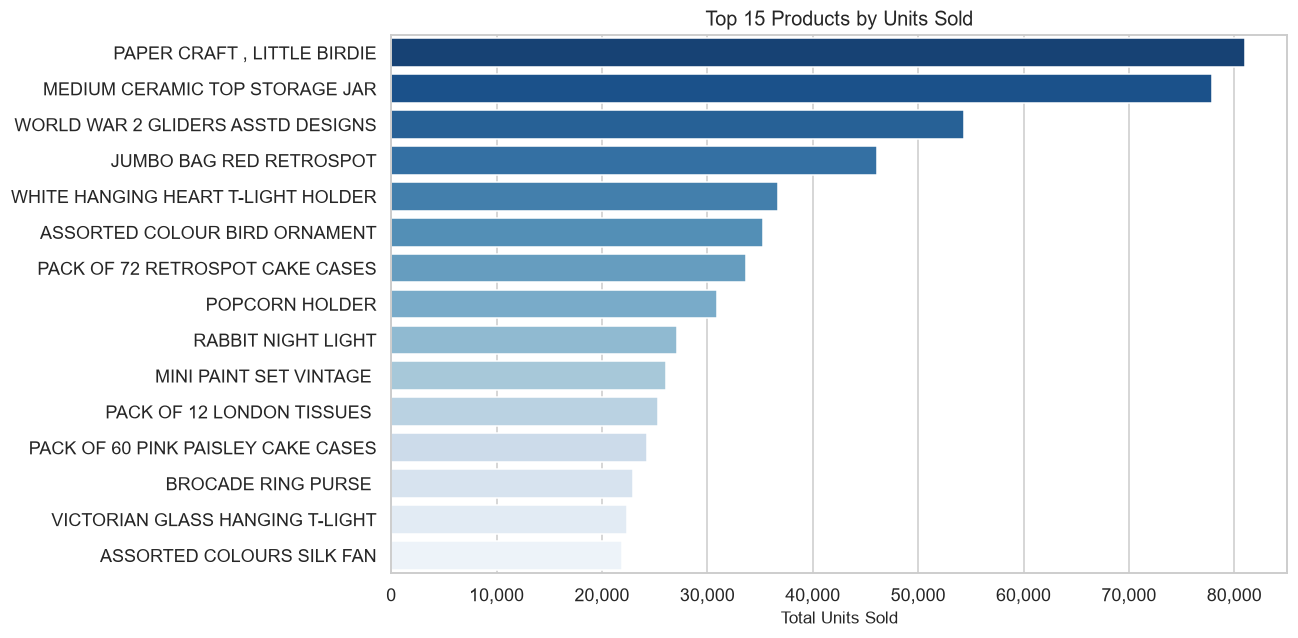

In [20]:
# Top 15 products by units sold
top_qty = (
    df.groupby('Description')['Quantity']
    .sum()
    .nlargest(15)
    .reset_index()
    .rename(columns={'Quantity': 'UnitsSold'})
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_qty, y='Description', x='UnitsSold',
            palette='Blues_r', ax=ax)
ax.set_title('Top 15 Products by Units Sold')
ax.set_xlabel('Total Units Sold')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

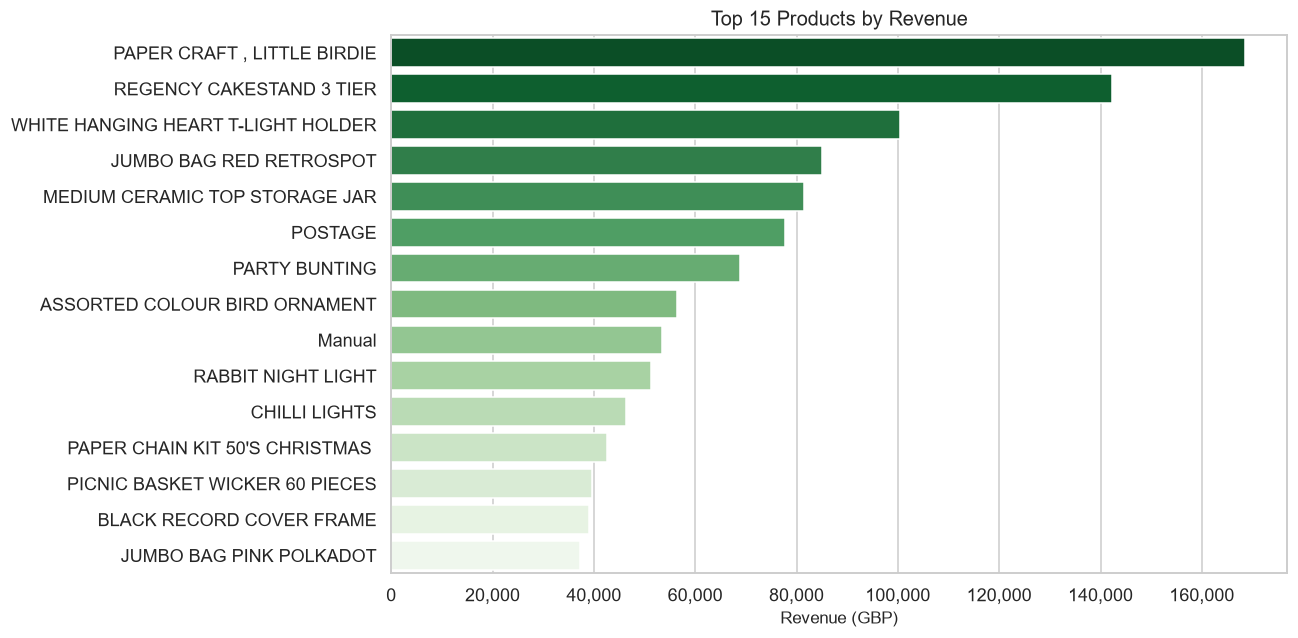

In [21]:
# Top 15 products by revenue
top_rev = (
    df.groupby('Description')['TotalRevenue']
    .sum()
    .nlargest(15)
    .reset_index()
    .rename(columns={'TotalRevenue': 'Revenue'})
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_rev, y='Description', x='Revenue',
            palette='Greens_r', ax=ax)
ax.set_title('Top 15 Products by Revenue')
ax.set_xlabel('Revenue (GBP)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

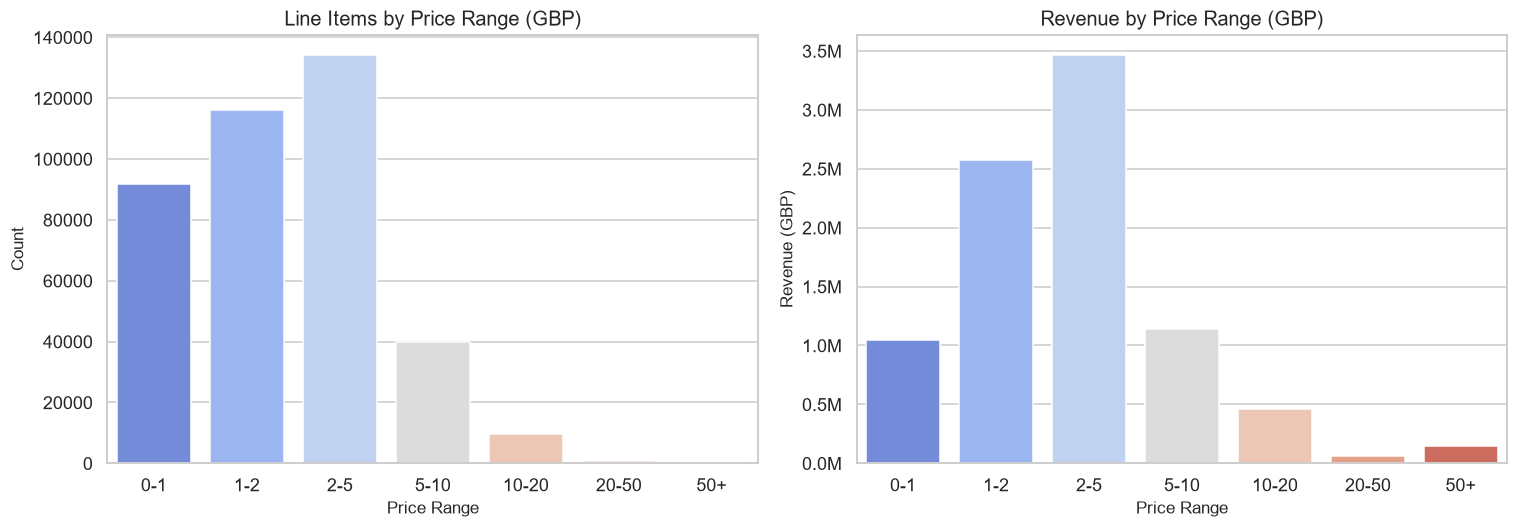

In [22]:
# Revenue and volume by price range
bins   = [0, 1, 2, 5, 10, 20, 50, np.inf]
labels = ['0-1', '1-2', '2-5', '5-10', '10-20', '20-50', '50+']
df['PriceRange'] = pd.cut(df['UnitPrice'], bins=bins, labels=labels, right=False)

price_rev   = df.groupby('PriceRange', observed=True)['TotalRevenue'].sum().reset_index()
price_count = df['PriceRange'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=price_count.index, y=price_count.values,
            palette='coolwarm', ax=axes[0])
axes[0].set_title('Line Items by Price Range (GBP)')
axes[0].set_xlabel('Price Range')
axes[0].set_ylabel('Count')

sns.barplot(data=price_rev, x='PriceRange', y='TotalRevenue',
            palette='coolwarm', ax=axes[1])
axes[1].set_title('Revenue by Price Range (GBP)')
axes[1].set_xlabel('Price Range')
axes[1].set_ylabel('Revenue (GBP)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

---
## 10. Geographic Analysis

In [23]:
# Revenue, orders, and customers per country
country_df = (
    df.groupby('Country')
    .agg(
        Revenue       = ('TotalRevenue', 'sum'),
        OrderCount    = ('InvoiceNo',    'nunique'),
        CustomerCount = ('CustomerID',   'nunique'),
    )
    .reset_index()
    .sort_values('Revenue', ascending=False)
)
country_df['Revenue_Share_%'] = (country_df['Revenue'] / country_df['Revenue'].sum() * 100).round(2)
country_df.head(10)

,Country,Revenue,OrderCount,CustomerCount,Revenue_Share_%
35,United Kingdom,"7,285,024.64",16646,3920,81.97
23,Netherlands,"285,446.34",94,9,3.21
10,EIRE,"265,262.46",260,3,2.98
14,Germany,"228,678.40",457,94,2.57
13,France,"208,934.31",389,87,2.35
0,Australia,"138,453.81",57,9,1.56
30,Spain,"61,558.56",90,30,0.69
32,Switzerland,"56,443.95",51,21,0.64
3,Belgium,"41,196.34",98,25,0.46
31,Sweden,"38,367.83",36,8,0.43


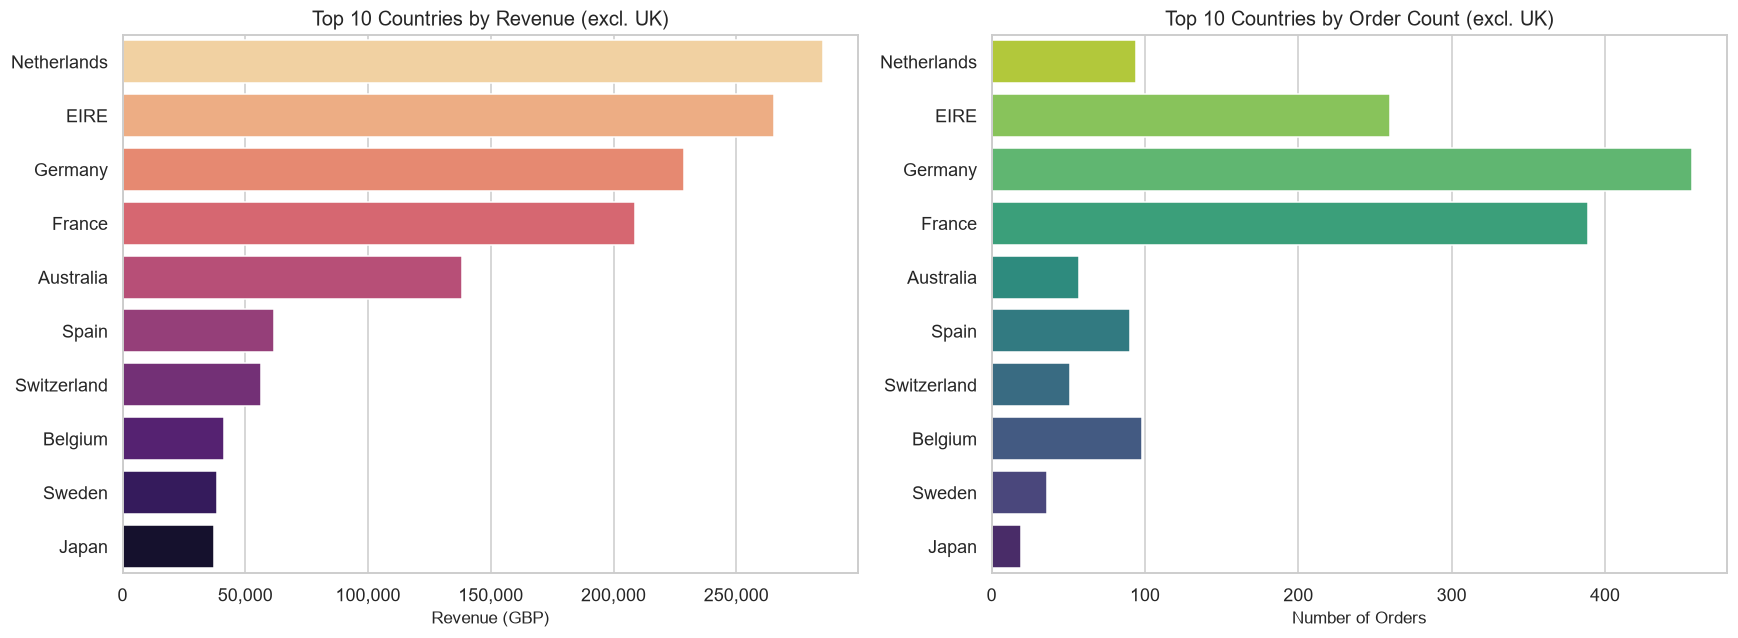

In [24]:
# Top 10 countries excluding United Kingdom (which dominates at ~85%)
top10_countries = country_df[country_df['Country'] != 'United Kingdom'].head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top10_countries, x='Revenue', y='Country',
            palette='magma_r', ax=axes[0])
axes[0].set_title('Top 10 Countries by Revenue (excl. UK)')
axes[0].set_xlabel('Revenue (GBP)')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

sns.barplot(data=top10_countries, x='OrderCount', y='Country',
            palette='viridis_r', ax=axes[1])
axes[1].set_title('Top 10 Countries by Order Count (excl. UK)')
axes[1].set_xlabel('Number of Orders')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

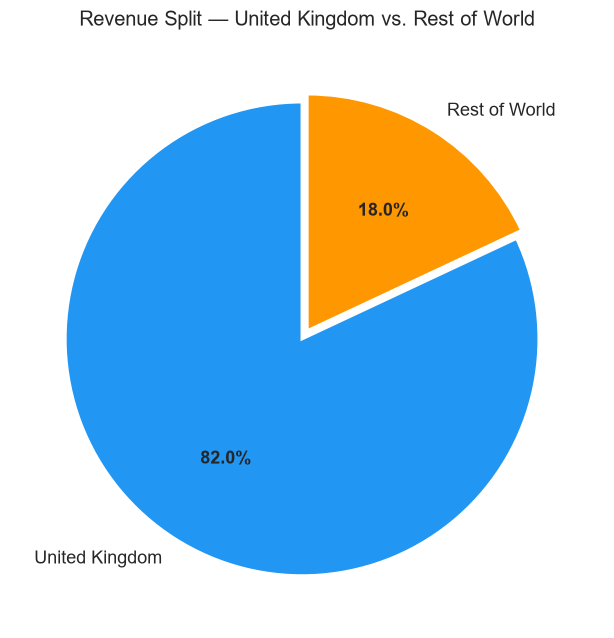

UK Revenue          : 7,285,024.64 GBP
Rest of World       : 1,602,184.25 GBP
UK Share            : 82.0%


In [25]:
# UK vs. Rest of World revenue split
uk_rev  = country_df.loc[country_df['Country'] == 'United Kingdom', 'Revenue'].values[0]
row_rev = country_df.loc[country_df['Country'] != 'United Kingdom', 'Revenue'].sum()

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    [uk_rev, row_rev],
    labels=['United Kingdom', 'Rest of World'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2196F3', '#FF9800'],
    wedgeprops=dict(edgecolor='white', linewidth=2),
    explode=(0.04, 0)
)
for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight('bold')
ax.set_title('Revenue Split — United Kingdom vs. Rest of World')
plt.tight_layout()
plt.show()

print(f'UK Revenue          : {uk_rev:>12,.2f} GBP')
print(f'Rest of World       : {row_rev:>12,.2f} GBP')
print(f'UK Share            : {uk_rev/(uk_rev+row_rev)*100:.1f}%')

---
## 11. Summary Dashboard

In [26]:
# Key performance indicators
total_revenue   = df['TotalRevenue'].sum()
total_orders    = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()
total_products  = df['StockCode'].nunique()
avg_order_value = df.groupby('InvoiceNo')['TotalRevenue'].sum().mean()
best_month      = monthly_revenue.loc[monthly_revenue['TotalRevenue'].idxmax(), 'YM_str']

print('=' * 55)
print('  KEY PERFORMANCE INDICATORS  |  Online Retail')
print('=' * 55)
print(f'  Total Revenue         : {total_revenue:>14,.2f} GBP')
print(f'  Total Orders          : {total_orders:>14,}')
print(f'  Unique Customers      : {total_customers:>14,}')
print(f'  Unique Products       : {total_products:>14,}')
print(f'  Avg Order Value       : {avg_order_value:>14,.2f} GBP')
print(f'  Peak Revenue Month    : {best_month:>14}')
print('=' * 55)

  KEY PERFORMANCE INDICATORS  |  Online Retail
  Total Revenue         :   8,887,208.89 GBP
  Total Orders          :         18,532
  Unique Customers      :          4,338
  Unique Products       :          3,665
  Avg Order Value       :         479.56 GBP
  Peak Revenue Month    :        2011-11


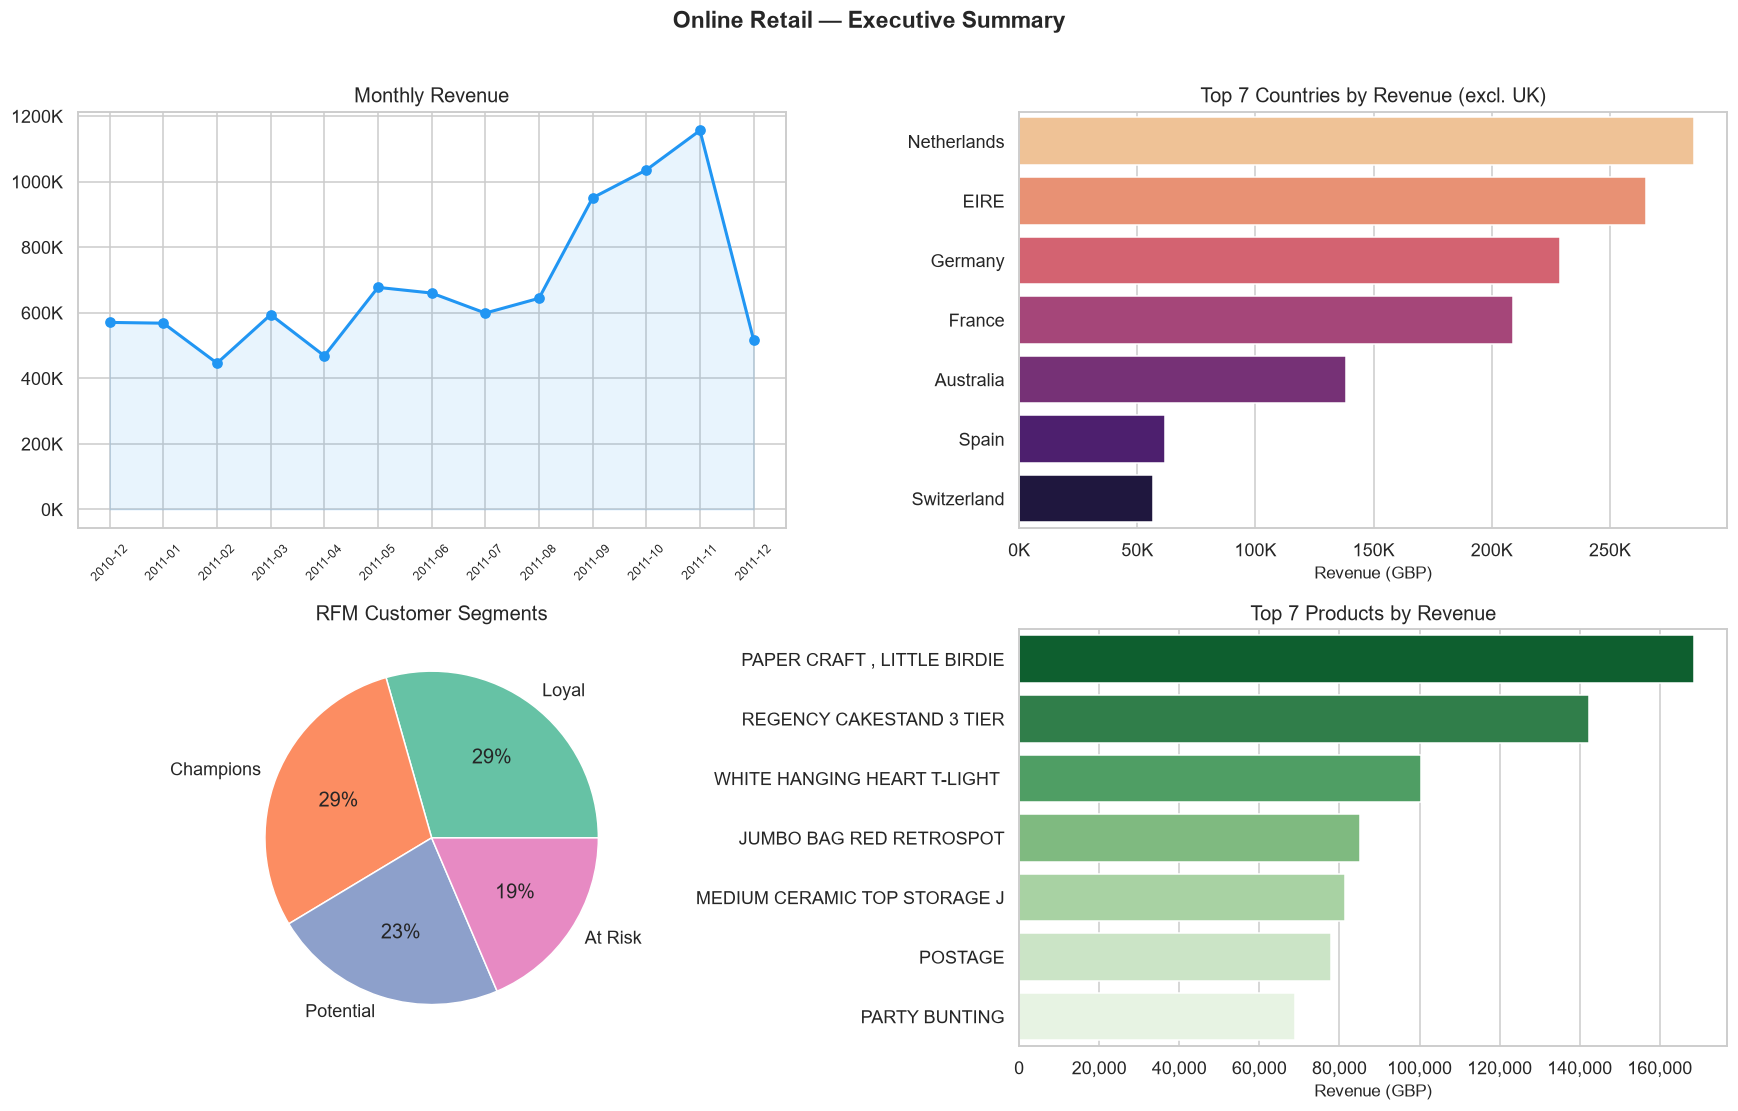

In [27]:
# Four-panel summary chart
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Online Retail — Executive Summary', fontsize=15, fontweight='bold', y=1.01)

# Panel 1: Monthly Revenue
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(monthly_revenue['YM_str'], monthly_revenue['TotalRevenue'],
         marker='o', color='#2196F3', linewidth=2)
ax1.fill_between(monthly_revenue['YM_str'], monthly_revenue['TotalRevenue'],
                 alpha=0.1, color='#2196F3')
ax1.set_title('Monthly Revenue')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax1.tick_params(axis='x', rotation=45, labelsize=8)

# Panel 2: Top 7 Countries by Revenue (excl. UK)
ax2 = fig.add_subplot(2, 2, 2)
sns.barplot(data=top10_countries.head(7), x='Revenue', y='Country',
            palette='magma_r', ax=ax2)
ax2.set_title('Top 7 Countries by Revenue (excl. UK)')
ax2.set_xlabel('Revenue (GBP)')
ax2.set_ylabel('')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Panel 3: RFM Segments
ax3 = fig.add_subplot(2, 2, 3)
seg_data = rfm['Segment'].value_counts()
ax3.pie(seg_data, labels=seg_data.index, autopct='%1.0f%%',
        colors=sns.color_palette('Set2', len(seg_data)),
        wedgeprops=dict(edgecolor='white'))
ax3.set_title('RFM Customer Segments')

# Panel 4: Top 7 Products by Revenue
ax4 = fig.add_subplot(2, 2, 4)
top7_rev = top_rev.head(7).copy()
top7_rev['Label'] = top7_rev['Description'].str[:28]
sns.barplot(data=top7_rev, x='Revenue', y='Label',
            palette='Greens_r', ax=ax4)
ax4.set_title('Top 7 Products by Revenue')
ax4.set_xlabel('Revenue (GBP)')
ax4.set_ylabel('')
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

---
## Findings

| # | Finding | Business Implication |
|---|---------|----------------------|
| 1 | Revenue peaks in November 2011 | Holiday season drives a significant sales uplift |
| 2 | United Kingdom accounts for ~85% of total revenue | Heavy dependence on home market; growth potential abroad |
| 3 | Top 10 customers contribute disproportionate revenue | VIP retention programs are high priority |
| 4 | Low-price items (1–5 GBP) dominate transaction volume | High-turnover, low-margin product mix |
| 5 | Peak trading hours are 10:00–15:00; Thursday is the best day | Schedule promotions and email campaigns accordingly |
| 6 | Champions segment (RFM) represents ~25% of customers | Focus retention efforts on this group |
| 7 | Germany and Netherlands are the leading international markets | Priority targets for EU marketing investment |